## Mutation-Level Comparison Model Workflow

This notebook reuses the mutation-level dataset curation logic from the current paper workflow and swaps in an alternative statistical model.
The 2021 supervised set, temporal reclassification benchmark, and 2023 release-side feature tables are all aligned to the mutation-level formulation.


## 1. Imports and Notebook Setup
This notebook evaluates the GAQQ comparison model using the same mutation-level data curation as the main paper workflow.


## Rerun Note

Recommended execution order: run top-to-bottom after a fresh kernel restart. 
These notebooks now use the mutation-level 2021 training set (`370 -> 345`) and the mutation-level 2021→2023 temporal benchmark (`81 -> 62`).

If a later metric cell fails with a missing variable, rerun the current section from its markdown header rather than executing individual cells out of order.


In [1]:
#GAQQ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


## 2. Shared Mutation-Level Data Curation
Here we load the paper-release feature tables, apply the same `Prox_3D` filter as the main notebook, and define helper functions for mutation-level supervised collapse and temporal reclassification.


In [2]:
# Load the paper-release feature tables and define mutation-level helpers
from pathlib import Path


def resolve_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]
    for candidate in candidates:
        if (candidate / 'paper_release/source_data/derived_features/2021/2021_final_df.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing paper_release/source_data')


PROJECT_ROOT = resolve_project_root()
DATA_2021 = PROJECT_ROOT / 'paper_release/source_data/derived_features/2021/2021_final_df.csv'
DATA_2023 = PROJECT_ROOT / 'paper_release/source_data/derived_features/2023/2023_final_df.csv'
print('Resolved PROJECT_ROOT:', PROJECT_ROOT)

BINARY_MAP = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

CONFIDENCE_PRIORITY = {
    '1) Assoc w R': 0,
    '2) Assoc w R - Interim': 1,
    '4) Not assoc w R - Interim': 2,
    '5) Not assoc w R': 3,
    '3) Uncertain significance': 4,
}


def load_release_features(path):
    df = pd.read_csv(path).copy()
    rename_map = {
        'mutation_oneletter': 'one_letter_mutation',
        'Rosetta_fa_atr': 'fa_atr',
        'Rosetta_fa_rep': 'fa_rep',
        'Rosetta_fa_sol': 'fa_sol',
        'Rosetta_fa_elec': 'fa_elec',
        'Rosetta_fa_dun': 'fa_dun',
        'Rosetta_ddG': 'thermostability',
        'Prox_3D_zeroed': 'Proximity_to_R_Conferring',
        'LLR_score': 'llr_score',
        'freq_variant': 'frequency',
        'AAIndex_mut1': 'mut_AAIndex1',
        'AAIndex_mut2': 'mut_AAIndex2',
        'AAIndex_mut3': 'mut_AAIndex3',
        'AAIndex_mut4': 'mut_AAIndex4',
        'AAIndex_mut5': 'mut_AAIndex5',
        'AAIndex_mut6': 'mut_AAIndex6',
        'AAIndex_mut7': 'mut_AAIndex7',
        'AAIndex_mut8': 'mut_AAIndex8',
    }
    df = df.rename(columns=rename_map)
    return df


def collapse_supervised_mutation_level(df):
    labeled = df[df['confidence'] != '3) Uncertain significance'].copy()
    labeled['_binary_confidence'] = labeled['confidence'].map(BINARY_MAP)
    labeled = labeled[labeled['_binary_confidence'].notna()].copy()
    pre_n = labeled.shape[0]
    labeled = labeled.drop_duplicates(subset=['gene', 'one_letter_mutation', '_binary_confidence']).copy()
    print(f'Collapsed supervised labeled set: {pre_n} -> {labeled.shape[0]} rows')
    return labeled.drop(columns=['_binary_confidence'])


def collapse_confidence_to_mutation_level(df, confidence_col='confidence'):
    rows = []
    for (gene, mut), sub in df.groupby(['gene', 'one_letter_mutation'], dropna=False):
        confs = [c for c in sub[confidence_col].dropna().tolist()]
        non_uncertain = [c for c in confs if c != '3) Uncertain significance']
        pool = non_uncertain if non_uncertain else confs
        chosen = sorted(pool, key=lambda c: CONFIDENCE_PRIORITY.get(c, 999))[0] if pool else np.nan
        first = sub.iloc[0].copy()
        first[confidence_col] = chosen
        rows.append(first)
    return pd.DataFrame(rows).reset_index(drop=True)


def merge_catalogs_mutation_level(df_2021, df_2023):
    df_2021_mut = collapse_confidence_to_mutation_level(df_2021, 'confidence')
    df_2023_mut = collapse_confidence_to_mutation_level(df_2023, 'confidence')
    merged_df = pd.merge(
        df_2021_mut,
        df_2023_mut,
        on=['gene', 'one_letter_mutation'],
        suffixes=('_2021', '_2023')
    )
    return merged_df.drop_duplicates()


catalog_data = load_release_features(DATA_2021)
catalog_data = catalog_data.drop_duplicates()
catalog_data = catalog_data[catalog_data['Prox_3D'].notna()].copy()
print(f'Catalog rows after Prox_3D filter: {catalog_data.shape[0]}')


Catalog rows after Prox_3D filter: 4248


In [3]:
# Filter out category 3 entries and collapse to mutation level
label_data = collapse_supervised_mutation_level(catalog_data)


Collapsed supervised labeled set: 370 -> 345 rows


In [4]:
# List of numeric columns to use as features
numeric_columns = [
    'fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun', 'thermostability',
    'Proximity_to_R_Conferring',
    'mut_AAIndex1', 'mut_AAIndex2', 'mut_AAIndex3', 'mut_AAIndex4',
    'mut_AAIndex5', 'mut_AAIndex6', 'mut_AAIndex7', 'mut_AAIndex8',
    'LLR_dim33', 'LLR_dim46', 'LLR_dim62', 'LLR_dim70', 'LLR_dim124',
    'LLR_dim192', 'LLR_dim207', 'LLR_dim258', 'LLR_dim267', 'LLR_dim315',
    'frequency'
]

label_data[numeric_columns] = label_data[numeric_columns].fillna(0)


In [5]:
# Extract the feature matrix and target vector
X_label = label_data[numeric_columns]
y_label= label_data['confidence']


## 3. Supervised Training Dataset
These cells construct the 2021 labeled mutation-level training set and prepare the features used by the GAQQ model.


In [6]:
print(X_label.shape, y_label.shape)


(345, 26) (345,)


In [7]:
# Convert the target variable to numeric labels
y_label = y_label.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0, # change 2 to 1 to run the logistic regression
    "5) Not assoc w R": 0
})


## 4. Holdout Split and Model Fitting
This section standardizes the features, performs the holdout split, and fits the GAQQ comparison model.


In [8]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_label, test_size=0.3, random_state=42)


In [9]:

# Map confidence levels to phenotypes
def map_confidence_to_phenotype(confidence):
    if confidence in ['1) Assoc w R', '2) Assoc w R - Interim']:
        return 'Resistant'
    elif confidence in ['4) Not assoc w R - Interim', '5) Not assoc w R']:
        return 'Susceptible'
    else:
        return 'Unknown'
    
catalog_data['phenotype'] =catalog_data['confidence'].apply(map_confidence_to_phenotype)
catalog_data['phenotype'].value_counts()


phenotype
Unknown        3878
Resistant       312
Susceptible      58
Name: count, dtype: int64

In [10]:
# In order to apply the GAQQ, the data would be seperated by this way:
X1 = X_train_split[y_train_split == 1]
X2 = X_train_split[y_train_split == 0]
X3 = X_test_split[y_test_split == 1]
X4 = X_test_split[y_test_split == 0]
# lambda is the penalty parameter
lambda1 = np.linspace(0.01, 5, 50)
lambda2 = np.linspace(0.01, 5, 50)


In [11]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

# Activate the automatic conversion between pandas DataFrames and R data frames
pandas2ri.activate()
# Get the R global environment
r = ro.r
# Load the R script
try:
    r['source']("est.twoclass.R") # have to change the path
    print("R script loaded successfully.")
except Exception as e:
    print(f"Error loading R script: {e}")


R[write to console]: Loading required package: Matrix

R[write to console]: Loaded glmnet 4.1-8



R script loaded successfully.


In [12]:
# def check_invalid_values(matrix, name):
#     if np.any(np.isnan(matrix)):
#         print(f"{name} contains NaN values.")
#     if np.any(np.isinf(matrix)):
#         print(f"{name} contains Inf values.")
#     if not np.any(np.isnan(matrix)) and not np.any(np.isinf(matrix)):
#         print(f"{name} is free from NaN and Inf values.")

# check_invalid_values(X1, "X1")
# check_invalid_values(X2, "X2")

# Retrieve functions from the R global environment
SLDA_EBIC = ro.globalenv['SLDA.EBIC']
classify = ro.globalenv['classify']
# lambda1 = np.linspace(0.01, 1, 100)
# lambda2 = np.linspace(0.01, 10, 100)

# Call the R function and obtain the result of GAQQ model
result = SLDA_EBIC(X1, X2, lambda1, lambda2)
# Extract the C_opt matrix from the result
C_opt = np.array(result.rx2('C_opt'))  # get C_opt
print("Type of C_opt:", type(C_opt))
print("C_opt matrix:")
print(C_opt)
print("Condition number:", np.linalg.cond(C_opt))


Type of C_opt: <class 'numpy.ndarray'>
C_opt matrix:
[[ 1.53060445e+00  4.17746976e-01  2.45062719e-01 -0.00000000e+00
   3.80286744e-01  3.60433333e-02  0.00000000e+00  8.79481120e-02
  -1.67243864e-01 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -9.20732902e-02 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00  3.65907462e-01 -0.00000000e+00  3.00409201e-02
  -0.00000000e+00  0.00000000e+00]
 [ 4.17739254e-01  2.48921076e+00 -0.00000000e+00 -0.00000000e+00
  -1.09592628e-01 -1.63797774e+00  0.00000000e+00 -0.00000000e+00
  -0.00000000e+00  4.78863445e-02 -1.82587761e-01 -2.08980590e-02
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  3.17243669e-02
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -6.95794804e-02
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  1.21728259e-02
   6.17714177e-03  0.00000000e+00]
 [ 2.45057556e-01 -0.00000000e+00  1.26979636e+00  3.21812251e-01
  -1.98518394e-01 -

In [13]:
delta_h_opt = result.rx2('delta_h_opt')
print(delta_h_opt)


[ 0.          0.09702699 -0.0280263   0.19494187  0.04925112  0.14450891
 -0.82571863 -0.00998122 -0.03377455 -0.1649639   0.          0.
 -0.05222254  0.         -0.05467401  0.          0.04673239  0.
  0.         -0.11490683  0.         -0.06192669  0.11425073  0.
  0.          1.00203413]


In [14]:
epsilon = 1e-8  # use this to avoid singular
C_opt_regularized = C_opt + epsilon * np.eye(C_opt.shape[0])
C_opt_r = ro.r.matrix(C_opt_regularized, nrow=C_opt_regularized.shape[0], ncol=C_opt_regularized.shape[1])
ro.globalenv['C_opt'] = C_opt_r

# run classify function, could be regards as prediction function
try:
    pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)
    print("Classify completed successfully.")
except Exception as e:
    print(f"Error during classify with regularized C_opt: {e}")

y_hat = np.array(pred_result.rx2('y_hat'))
error = pred_result.rx2('error')[0]
rmse = pred_result.rx2('rmse')[0]
est_label = np.array(pred_result.rx2('est_label'))


Classify completed successfully.


In [15]:
print(y_hat) # this is the estimation of frequency


[ 0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098 -1.74268727  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098 -1.74268727  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098  0.26138098
  0.26138098  0.26138098  0.26138098  0.26138098  0

In [16]:
print(rmse) # rmse of frequency in the 2021 test set


0.82847658446373


In [17]:
# cuaculate the classification result on the test set
y_pred = 1 - est_label
correct_predictions = y_pred == y_test_split
accuracy = np.mean(correct_predictions)
print(accuracy) 


0.75


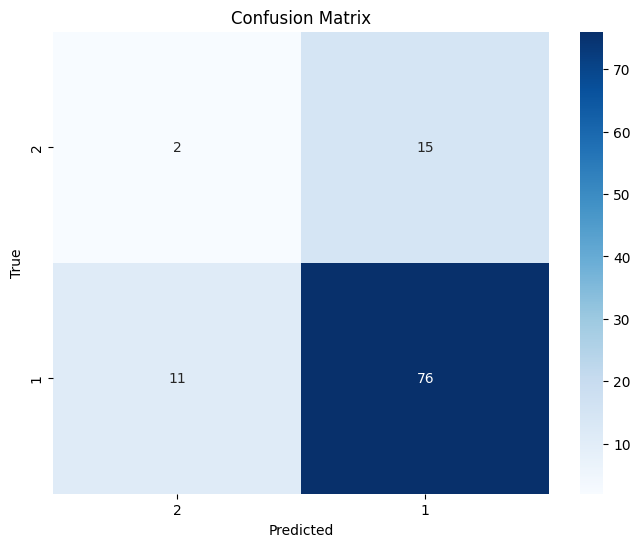

In [18]:
cm = confusion_matrix(y_test_split,  y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [19]:
print(classification_report(y_test_split, y_pred ))


              precision    recall  f1-score   support

           0       0.15      0.12      0.13        17
           1       0.84      0.87      0.85        87

    accuracy                           0.75       104
   macro avg       0.49      0.50      0.49       104
weighted avg       0.72      0.75      0.74       104



## Make the prediction on the 2023 changed data

## 5. Temporal Reclassification Benchmark
We collapse 2021 and 2023 confidence calls to mutation level, merge the two catalogues, and measure how many mutations stayed uncertain versus moved out of Category 3.


In [20]:
from IPython.display import display
import pandas as pd

# Load the 2021 and 2023 datasets
file_2021 = DATA_2021
file_2023 = DATA_2023

df_2021 = load_release_features(file_2021)
df_2023 = load_release_features(file_2023)
df_2021 = df_2021[df_2021['Prox_3D'].notna()].copy()
df_2023 = df_2023[df_2023['Prox_3D'].notna()].copy()


In [21]:
# Collapse both years to mutation level, then merge on gene + mutation
merged_df = merge_catalogs_mutation_level(df_2021, df_2023)


In [22]:

# Filter rows where confidence remained unchanged in category 3
unchanged_category_3 = merged_df[
    (merged_df['confidence_2021'] == "3) Uncertain significance") &
    (merged_df['confidence_2023'] == "3) Uncertain significance")
]
unchanged_category_3 = unchanged_category_3.drop_duplicates()

# Count the number of positions where the confidence remained unchanged
num_unchanged = unchanged_category_3.shape[0]

print(f"Number of positions where confidence remained unchanged in category 3: {num_unchanged}")

# Optional preview of unchanged rows (can be skipped if the table is too large)
display(unchanged_category_3[['gene', 'one_letter_mutation', 'confidence_2021', 'confidence_2023']])


Number of positions where confidence remained unchanged in category 3: 3114


,gene,one_letter_mutation,confidence_2021,confidence_2023
0,ddn,A120S,3) Uncertain significance,3) Uncertain significance
1,ddn,E83D,3) Uncertain significance,3) Uncertain significance
2,ddn,F66S,3) Uncertain significance,3) Uncertain significance
3,ddn,G34E,3) Uncertain significance,3) Uncertain significance
4,ddn,G34R,3) Uncertain significance,3) Uncertain significance
...,...,...,...,...
3515,tlyA,V178A,3) Uncertain significance,3) Uncertain significance
3516,tlyA,V198G,3) Uncertain significance,3) Uncertain significance
3517,tlyA,V32L,3) Uncertain significance,3) Uncertain significance
3518,tlyA,V7F,3) Uncertain significance,3) Uncertain significance


In [23]:
# Exclude rows where confidence is "3) Uncertain significance" in both files
filtered_df = merged_df[
    ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
      (merged_df['confidence_2023'] == "3) Uncertain significance"))
]

# Identify rows where confidence values differ between 2021 and 2023
updated_confidence = filtered_df[
    filtered_df['confidence_2021'] != filtered_df['confidence_2023']
]


In [24]:
filtered_df=filtered_df.drop_duplicates()


In [25]:
# Check for rows where confidence is 3 in both 2021 and 2023
confidence_3_in_both = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] == "3) Uncertain significance")
]

# Display the result
print(f"Number of rows with confidence 3 in both 2021 and 2023: {confidence_3_in_both.shape[0]}")
print(confidence_3_in_both)


Number of rows with confidence 3 in both 2021 and 2023: 0
Empty DataFrame
Columns: [gene, drug_2021, confidence_2021, phenotype_2021, one_letter_mutation, mutation_wt_2021, mutation_pos_2021, mutation_mut_2021, frequency_2021, fa_atr_2021, fa_rep_2021, fa_sol_2021, fa_elec_2021, fa_dun_2021, thermostability_2021, DeltaZ_2021, Prox_WHO_Adjusted_Pos_2021, Prox_1D_2021, Prox_1D_nearest_2021, Prox_3D_2021, Prox_3D_nearest_2021, Proximity_to_R_Conferring_2021, llr_score_2021, LLR_dim33_2021, LLR_dim46_2021, LLR_dim62_2021, LLR_dim70_2021, LLR_dim124_2021, LLR_dim192_2021, LLR_dim207_2021, LLR_dim258_2021, LLR_dim267_2021, LLR_dim315, AAIndex_delta1_2021, AAIndex_delta2_2021, AAIndex_delta3_2021, AAIndex_delta4_2021, AAIndex_delta5_2021, AAIndex_delta6_2021, AAIndex_delta7_2021, AAIndex_delta8_2021, mut_AAIndex1_2021, mut_AAIndex2_2021, mut_AAIndex3_2021, mut_AAIndex4_2021, mut_AAIndex5_2021, mut_AAIndex6_2021, mut_AAIndex7_2021, mut_AAIndex8_2021, mutation, drug_2023, confidence_2023, pheno

In [26]:
# Filter for confidence_2021 == "3) Uncertain significance" that changed to other categories
confidence_3_changed = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] != "3) Uncertain significance")
]
confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence_2021','confidence_2023'])
# Count value occurrences in confidence_2023
changed_counts = confidence_3_changed['confidence_2023'].value_counts()

# Display the result
print(f"Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: {confidence_3_changed.shape[0]}")
print("Value counts of the changed categories in 2023:")
print(changed_counts)


Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: 62
Value counts of the changed categories in 2023:
confidence_2023
2) Assoc w R - Interim        44
1) Assoc w R                  13
4) Not assoc w R - Interim     4
5) Not assoc w R               1
Name: count, dtype: int64


In [27]:
# Convert the target var 
 

mapping = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

confidence_3_changed['confidence_2023'] = confidence_3_changed['confidence_2023'].map(mapping)

print(confidence_3_changed[['confidence_2021', 'confidence_2023']])
print(confidence_3_changed['confidence_2023'].unique())


                confidence_2021  confidence_2023
639   3) Uncertain significance                1
790   3) Uncertain significance                1
823   3) Uncertain significance                1
952   3) Uncertain significance                1
1042  3) Uncertain significance                1
...                         ...              ...
2802  3) Uncertain significance                1
2816  3) Uncertain significance                1
2820  3) Uncertain significance                1
2827  3) Uncertain significance                1
2837  3) Uncertain significance                1

[62 rows x 2 columns]
[1 0]


## 6. Temporal Evaluation Set Construction
`category_3_data` is the mutation-level evaluation set: it contains only 2021 uncertain mutations that were later reclassified in 2023. This should have 62 rows in the current mutation-level workflow.


In [28]:
# Step 0: Collapse the 2021 uncertain set to one row per mutation
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']].drop_duplicates()
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"].copy()
category_3_data = category_3_data.drop_duplicates(subset=['gene', 'one_letter_mutation'])
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')

print(f"Shape of mutation-level category_3_data: {category_3_data.shape}")


Shape of mutation-level category_3_data: (62, 51)


This section predicts on the mutation-level temporal evaluation set using `category_3_data`. The redundant pre-evaluation `classify(...)` call was removed to avoid stale in-memory outputs.


In [30]:
# Predict on the mutation-level temporal evaluation set with GAQQ
X3 = X_category_3[category_3_data['confidence_2023'] == 1]
X4 = X_category_3[category_3_data['confidence_2023'] == 0]
pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)

y_hat = np.array(pred_result.rx2('y_hat'))
error = pred_result.rx2('error')[0]
rmse = pred_result.rx2('rmse')[0]
est_label = np.array(pred_result.rx2('est_label'))

y_true_cat3 = category_3_data['confidence_2023'].to_numpy()
y_pred_cat3 = 1 - est_label

print('Temporal set size:', len(y_true_cat3))
print('Prediction size:', len(y_pred_cat3))
assert len(y_true_cat3) == len(y_pred_cat3), 'Temporal labels/predictions length mismatch'


Temporal set size: 62
Prediction size: 62


In [31]:

rmse # rmse of frequency 


1.1770182953242627

In [32]:
error # error of classification


12.0

## 7. Temporal Evaluation Metrics
These cells report confusion-matrix, classification, and error-rate summaries for the GAQQ model on the mutation-level temporal benchmark.


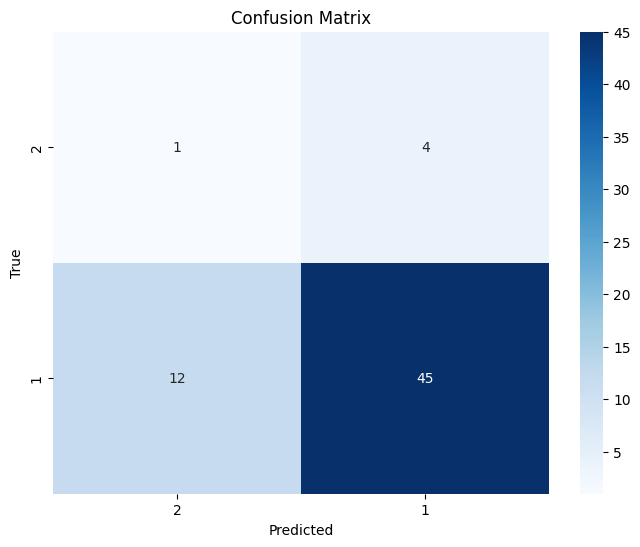

In [33]:
cm = confusion_matrix(y_true_cat3, y_pred_cat3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [34]:
print(classification_report(y_true_cat3, y_pred_cat3))


              precision    recall  f1-score   support

           0       0.08      0.20      0.11         5
           1       0.92      0.79      0.85        57

    accuracy                           0.74        62
   macro avg       0.50      0.49      0.48        62
weighted avg       0.85      0.74      0.79        62



In [35]:
tn, fp, fn, tp = confusion_matrix(y_true_cat3, y_pred_cat3).ravel()

# calculate type1 and type 2 error
type_1_error = fp / (fp + tn)  # False Positive Rate
type_2_error = fn / (fn + tp)  # False Negative Rate

print(f"Type I Error (False Positive Rate): {type_1_error:.4f}")
print(f"Type II Error (False Negative Rate): {type_2_error:.4f}")


Type I Error (False Positive Rate): 0.8000
Type II Error (False Negative Rate): 0.2105
